# Predictive Maintenance: Machine Failure Classification
Using sensor data from manufacturing equipment, this project builds and 
evaluates multiple classification models to predict machine failures before they occur — enabling proactive maintenance and reducing downtime.

## Notable Changes

During the EDA, the assumption was made that the model would be predicting machine_failure (binary) due to perceived challenges with multi dimensional targets, and determining how to address predicting multiple failures within a machine.

After working through this direction in the technical notebook, the decision was made to pivot to predicting primary_failure. As a result there are slight differences between the EDA and the approach taken here.

## Imports

In [ ]:
import pandas as pd

import os

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

Dataset: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020

In [ ]:
df = pd.read_csv('ai4i2020.csv')

Using Colab cache for faster access to the 'predictive-maintenance-dataset-ai4i-2020' dataset.


## Understanding Column Descriptions
* UDI = Unique Identifier
* Product ID = L (low), M (medium), H (high) + serial number
* Type = L, M, H
* Air Temp = normalized to a standard deviation of 2K around 300K
* Process Temp = normalized to a standard deviation of 1K, added to the air temperature + 10K
* Rotation Speed = calculated from a power of 2860W
* Torque = distributed around 40Nm with a SD=10Nm, no negative values
* Tool Wear = variants H/M/L add 5/3/2 minutes of tool wear
* Machine Failure = 0 False, 1 True
* Tool Wear Failure (twf) = the tool will be replaced of fail at a randomly selected tool wear time between 200-240 mins
* Heat Dissipation Failure (HDF) = if the difference between air and process temperature is below 8.6K and the tools rotational speed is below 1380rpm
* Power Failure (PWF) = is below 3500W or above 9000W, the process fails
* Overstrain Failure (OSF) = if the product of tool wear and torque exceeds 11,000minNm for the L product variant (12,000M, 13,000H), the process fails due to overstrain
* Random Failures (RNF) = has a chance of 0.1 % to fail

## Column Name Clean Up

In [ ]:
df.columns = df.columns.str.replace(' ', '_', regex=False).str.lower()

## Add new columns that were created during the EDA
- Create overstrain_metric column to determine the calcuated value of tool_wear and torque
- Create temp_diff column to determine the difference between process_ and air_ temperature
- Add dummies for type (L, M, H)
- Create primary_failure column for target

In [ ]:
# Calculation to determine likelihood of osf
df['overstrain_metric'] = df['tool_wear_[min]'] * df['torque_[nm]']

# Difference helps detect hdf
df['temp_diff'] = df['process_temperature_[k]'] - df['air_temperature_[k]']

# Estimates power delivered by the machine and possible conditions leading to pwf
df['power_estimate'] = df['torque_[nm]'] * df['rotational_speed_[rpm]']

In [ ]:
# Create dummies based on type
type_dummies = pd.get_dummies(df['type'], prefix='type', dtype=int)
df = pd.concat([df, type_dummies], axis=1)

In [ ]:
# Approach to handling multiple failures per machine
# Prioritize failures based on safety and ability to predict
# If a machine has multiple failures instead of setting failure_type to "Multiple" and lose data
# set primary_failure based on prioritization

priority = ["pwf", "osf", "hdf", "twf", "rnf"]

def primary_failure(row):
  for f in priority:
    if row[f] == 1:
      return f.upper()
  if row["machine_failure"] == 1:
    return "Unknown"
  return "No Failure"

In [ ]:
df["primary_failure"] = df.apply(primary_failure, axis=1)

In [ ]:
df.sample(5)

,udi,product_id,type,air_temperature_[k],process_temperature_[k],rotational_speed_[rpm],torque_[nm],tool_wear_[min],machine_failure,twf,...,osf,rnf,overstrain_metric,temp_diff,power_estimate,type_H,type_L,type_M,primary_failure,predicted_failure
3480,3481,L50660,L,301.9,310.8,1400,58.2,79,0,0,...,0,0,4597.8,8.9,81480.0,0,1,0,No Failure,No Failure
9481,9482,L56661,L,298.9,309.6,1365,50.9,183,0,0,...,0,0,9314.7,10.7,69478.5,0,1,0,No Failure,No Failure
3284,3285,H32698,H,301.2,309.9,1362,50.7,25,0,0,...,0,0,1267.5,8.7,69053.4,1,0,0,No Failure,No Failure
3023,3024,L50203,L,300.4,309.5,1711,29.2,215,0,0,...,0,0,6278.0,9.1,49961.2,0,1,0,No Failure,No Failure
332,333,M15192,M,297.6,308.3,1538,40.2,0,0,0,...,0,0,0.0,10.7,61827.6,0,0,1,No Failure,No Failure


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   product_id               10000 non-null  object 
 2   type                     10000 non-null  object 
 3   air_temperature_[k]      10000 non-null  float64
 4   process_temperature_[k]  10000 non-null  float64
 5   rotational_speed_[rpm]   10000 non-null  int64  
 6   torque_[nm]              10000 non-null  float64
 7   tool_wear_[min]          10000 non-null  int64  
 8   machine_failure          10000 non-null  int64  
 9   twf                      10000 non-null  int64  
 10  hdf                      10000 non-null  int64  
 11  pwf                      10000 non-null  int64  
 12  osf                      10000 non-null  int64  
 13  rnf                      10000 non-null  int64  
 14  overstrain_metric      

## Objective

To predict machine failures before they occur so manufacturers can perform proactive maintenance.

Target: `primary_failure` (e.g., TWF, OSF, PWF, HDF, RNF, Unknown, No Failure).

Prioritize recall for failures. A false negative (predicting no failure when one occurs) is far costly than a false positive as it is unscheduled maintenance, introduces emergency repairs, and potential safety hazard.

In [ ]:
target = df['primary_failure']

## Feature Selection

Raw sensor readings:

* rotation_speed_[rpm]
* torque_[nm]
* tool_wear_[min]

Engineered data:

* overstrain_metric = tool_wear_[min] * torque_[nm]
* temp_diff = process_temperature_[k] - air_temperature_[k]
* power_estimated = torque_[nm] * rotational_speed_[rpm]
* type_H, type_M, type_L

Exclude:

* udi, product_id as they are identifier columns
* twf, hdf, pwf, osf, rnf, and primary_failure as they could leak information about failures
* air_temperature_[k], process_temperature_[k] as the temp_diff is more valuable based on its used to calculated hdf

In [ ]:
features = df[['rotational_speed_[rpm]', 'torque_[nm]', 'tool_wear_[min]', 'overstrain_metric', 'temp_diff', 'power_estimate', 'type_H', 'type_M', 'type_L']]

## Model Evaluation

Explore and compare models using:
* KNN
* Logistic Regression
* Decision Tree
* Random Forest
* Bagged Decision Trees

Each model will have a:
* Pipeline
* Param Grid
* Scorer = recall_weighted
* CV

Then the grid will be fitted on the features and target. And the best_params and cross_val_score for the grid will be printed to evaluate the model

### KNN

In [ ]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 10],
    'knn__weights': ['uniform', 'distance']
}

In [ ]:
knn_cv = StratifiedKFold(n_splits=5, shuffle=True)

In [ ]:
knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="recall_weighted",
    cv=knn_cv
)

In [ ]:
knn_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7, 10],
                         'knn__weights': ['uniform', 'distance']},
             scoring='recall_weighted')

In [ ]:
print(knn_grid.best_params_)

{'knn__n_neighbors': 3, 'knn__weights': 'uniform'}


In [ ]:
knn_scores = cross_val_score(
    estimator=knn_pipeline,
    X=features,
    y=target,
    cv=knn_cv,
    scoring="recall_weighted"
)

In [ ]:
print(knn_scores)
print(knn_scores.mean())

[0.9715 0.977  0.9765 0.9755 0.974 ]
0.9749000000000001


### Logistic Regression

In [ ]:
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

logreg_param_grid = {
  'logreg__C': [0.01, 0.1, 1, 10],
  'logreg__penalty': ['l2']
}

In [ ]:
logreg_cv = StratifiedKFold(n_splits=5, shuffle=True)

In [ ]:
logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring="recall_weighted",
    cv=logreg_cv
)

In [ ]:
logreg_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'logreg__C': [0.01, 0.1, 1, 10],
                         'logreg__penalty': ['l2']},
             scoring='recall_weighted')

In [ ]:
print(logreg_grid.best_params_)

{'logreg__C': 10, 'logreg__penalty': 'l2'}


In [ ]:
logreg_scores = cross_val_score(
    estimator=logreg_pipeline,
    X=features,
    y=target,
    cv=logreg_cv,
    scoring="recall_weighted"
)

In [ ]:
print(logreg_scores)
print(logreg_scores.mean())

[0.9795 0.979  0.976  0.981  0.977 ]
0.9785


### Decision Trees

In [ ]:
dt_pipeline = Pipeline([ ('classifier', DecisionTreeClassifier())])
dt_param_grid = {
  'classifier__max_depth': [3, 5, 7, 10],
  'classifier__min_samples_split': [2, 5, 10],
  'classifier__min_samples_leaf': [1, 2, 4],
  'classifier__criterion': ['gini', 'entropy']
}

In [ ]:
dt_cv = StratifiedKFold(n_splits=5, shuffle=True)

In [ ]:
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="recall_weighted",
    cv=dt_cv
)

In [ ]:
dt_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        DecisionTreeClassifier())]),
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 5, 7, 10],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='recall_weighted')

In [ ]:
print(dt_grid.best_params_)

{'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}


In [ ]:
dt_scores = cross_val_score(
    estimator=dt_pipeline,
    X=features,
    y=target,
    cv=dt_cv,
    scoring="recall_weighted"
)

In [ ]:
print(dt_scores)
print(dt_scores.mean())

[0.987  0.983  0.982  0.988  0.9845]
0.9849


### Random Forest

In [ ]:
rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier())
])

# When running fit the first couple times it was taking over 5+ and there was no conclusion
# Therefore reduced the number of  param options to run
rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 7],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__criterion': ['gini']
}

In [ ]:
# Reduced to 3 splits from 5 as the fitting was taking over 5 minutes to run
rf_cv = StratifiedKFold(n_splits=3, shuffle=True)

In [ ]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="recall_weighted",
    cv=rf_cv,
    n_jobs=1, # To help with performance when running locally
)

In [ ]:
rf_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        RandomForestClassifier())]),
             n_jobs=1,
             param_grid={'classifier__criterion': ['gini'],
                         'classifier__max_depth': [5, 7],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='recall_weighted')

In [ ]:
print(rf_grid.best_params_)

{'classifier__criterion': 'gini', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [ ]:
rf_scores = cross_val_score(
    estimator=rf_pipeline,
    X=features,
    y=target,
    cv=rf_cv,
    scoring="recall_weighted"
)

In [ ]:
print(rf_scores)
print(rf_scores.mean())

[0.9910018  0.99009901 0.99129913]
0.9907999798180178


### Bagged Decision Trees

In [ ]:
bag_pipeline = Pipeline([
    ('classifier', BaggingClassifier(
        estimator=DecisionTreeClassifier()
    ))
])

# When running fit the first couple times it was taking over 5+ and there was no conclusion
# Therefore reduced the number of  param options to run
bag_param_grid = {
    'classifier__n_estimators': [10, 50],
    'classifier__max_samples': [0.7, 1.0],
    'classifier__max_features': [0.7, 1.0],
    'classifier__estimator__max_depth': [3, 5],
    'classifier__estimator__min_samples_split': [2, 5]
}

In [ ]:
# Reduced to 3 splits from 5 as the fitting was taking over 5 minutes to run
bag_cv = StratifiedKFold(n_splits=3, shuffle=True)

In [ ]:
bag_grid = GridSearchCV(
    estimator=bag_pipeline,
    param_grid=bag_param_grid,
    scoring="recall_weighted",
    cv=bag_cv,
    n_jobs=1 # To help with performance running a fit
)

In [ ]:
bag_grid.fit(features, target)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('classifier',
                                        BaggingClassifier(estimator=DecisionTreeClassifier()))]),
             n_jobs=1,
             param_grid={'classifier__estimator__max_depth': [3, 5],
                         'classifier__estimator__min_samples_split': [2, 5],
                         'classifier__max_features': [0.7, 1.0],
                         'classifier__max_samples': [0.7, 1.0],
                         'classifier__n_estimators': [10, 50]},
             scoring='recall_weighted')

In [ ]:
print(bag_grid.best_params_)

{'classifier__estimator__max_depth': 5, 'classifier__estimator__min_samples_split': 2, 'classifier__max_features': 1.0, 'classifier__max_samples': 0.7, 'classifier__n_estimators': 50}


In [ ]:
bag_scores = cross_val_score(
    estimator=bag_pipeline,
    X=features,
    y=target,
    cv=bag_cv,
    scoring="recall_weighted"
)

In [ ]:
print(bag_scores)
print(bag_scores.mean())

[0.9910018  0.99129913 0.98949895]
0.9905999598160177


### Observations

| Model                 | CV Mean Accuracy |
| --------------------- | ---------------- |
| KNN                   | 0.9749           |
| Logistic Regression   | 0.9785           |
| Decision Tree         | 0.9849           |
| Random Forest         | 0.9907           |
| Bagged Decision Trees | 0.9905           |





Top performers: Random Forest and Bagged Decision Trees

Had to change the param_grid values for both Random Forest and Bagged Decision Trees because of performance. These are at 3 splits instead and have a smaller number of param options compared to Decision Tree.

Final decision: Random Forest as it has the best overall performance, and interpretability.

## Final Model

Random Forest

Best Params:
```
{'classifier__criterion': 'gini', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
```

In [ ]:
final_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(
        criterion='gini',
        max_depth=7,
        min_samples_leaf=1,
        min_samples_split=5,
        n_estimators=100,
    ))
])

In [ ]:
final_pipeline.fit(features, target)

Pipeline(steps=[('classifier',
                 RandomForestClassifier(max_depth=7, min_samples_split=5))])

In [ ]:
final_cv = StratifiedKFold(n_splits=5, shuffle=True)

In [ ]:
predicted_failures = cross_val_predict(final_pipeline, features, target, cv=final_cv)

In [ ]:
# Classification Report as a Summary
print(classification_report(target, predicted_failures))

              precision    recall  f1-score   support

         HDF       0.98      0.85      0.91       106
  No Failure       0.99      1.00      1.00      9643
         OSF       0.99      0.95      0.97        86
         PWF       1.00      0.98      0.99        95
         RNF       0.00      0.00      0.00        18
         TWF       0.00      0.00      0.00        43
     Unknown       0.00      0.00      0.00         9

    accuracy                           0.99     10000
   macro avg       0.57      0.54      0.55     10000
weighted avg       0.98      0.99      0.99     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Predictions vs. Actuals


In [ ]:
df['predicted_failure'] = predicted_failures

In [ ]:
df.sample(10)

,udi,product_id,type,air_temperature_[k],process_temperature_[k],rotational_speed_[rpm],torque_[nm],tool_wear_[min],machine_failure,twf,...,osf,rnf,overstrain_metric,temp_diff,power_estimate,type_H,type_L,type_M,primary_failure,predicted_failure
6891,6892,L54071,L,300.9,311.5,1505,41.1,129,0,0,...,0,0,5301.9,10.6,61855.5,0,1,0,No Failure,No Failure
5012,5013,M19872,M,303.8,312.9,1815,27.8,66,0,0,...,0,0,1834.8,9.1,50457.0,0,0,1,No Failure,No Failure
2073,2074,L49253,L,299.6,309.4,1677,31.1,191,0,0,...,0,0,5940.1,9.8,52154.7,0,1,0,No Failure,No Failure
3247,3248,M18107,M,301.0,309.8,1594,31.1,143,0,0,...,0,0,4447.3,8.8,49573.4,0,0,1,No Failure,No Failure
1571,1572,L48751,L,298.3,308.4,1528,37.3,160,0,0,...,0,0,5968.0,10.1,56994.4,0,1,0,No Failure,No Failure
1406,1407,L48586,L,298.9,310.1,1442,48.0,181,0,0,...,0,0,8688.0,11.2,69216.0,0,1,0,No Failure,No Failure
1952,1953,L49132,L,298.0,307.8,1266,60.5,81,0,0,...,0,0,4900.5,9.8,76593.0,0,1,0,No Failure,No Failure
6923,6924,L54103,L,301.2,311.7,1433,49.3,206,0,0,...,0,0,10155.8,10.5,70646.9,0,1,0,No Failure,No Failure
9059,9060,L56239,L,297.2,308.3,1805,25.6,103,0,0,...,0,0,2636.8,11.1,46208.0,0,1,0,No Failure,No Failure
6392,6393,L53572,L,300.1,309.7,1680,33.8,140,0,0,...,0,0,4732.0,9.6,56784.0,0,1,0,No Failure,No Failure


In [ ]:
# How many predictions were correct?
correct_prediction = predicted_failures == target
print(correct_prediction.value_counts())

primary_failure
True     9906
False      94
Name: count, dtype: int64


Of 10,000 datapoints, 9,906 were predicted correctly and 94 were predicted incorrectly. However, these include "No Failure" which dominates this dataset.



In [ ]:
correctly_detected_failures = df[
    (df['primary_failure'] != 'No Failure') &
    (df['predicted_failure'] == df['primary_failure'])
]

In [ ]:
num_correct_failures = len(correctly_detected_failures)

In [ ]:
num_total_failures = len(df[df['primary_failure'] != 'No Failure'])

In [ ]:
failure_recall = num_correct_failures / num_total_failures
failure_recall

0.742296918767507

When reviewing only actual failures, the model achieves a recall of 0.74, indicating that it correctly identifies approximately 3 out of 4 failures.

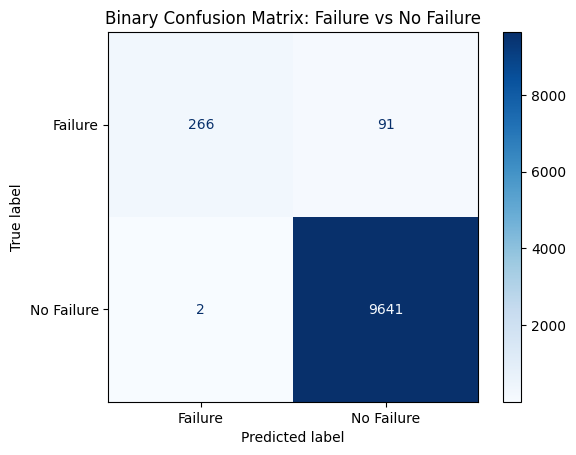

In [ ]:
df['actual_binary'] = df['primary_failure'].apply(lambda x: 'Failure' if x != 'No Failure' else 'No Failure')
df['pred_binary'] = df['predicted_failure'].apply(lambda x: 'Failure' if x != 'No Failure' else 'No Failure')
cm = confusion_matrix(df['actual_binary'], df['pred_binary'], labels=['Failure', 'No Failure'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'No Failure'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Binary Confusion Matrix: Failure vs No Failure")
plt.show()

While the model is multi-class, I evaluated performance in a binary sense (Failure vs No Failure) to summarize recall and false alarms across all failure types.

Of 357 actual failures, 266 were correctly detected (True Positives) and 91 were missed (False Negatives), resulting in a failure recall of 0.742.

False alarms were minimal, with only 2 False Positives resulting in a precision of 0.993.

#### How many failures were missed?
92

In [ ]:
missed_failures = df[(df['primary_failure'] != 'No Failure') &
                     (df['predicted_failure'] != df['primary_failure'])]

In [ ]:
missed_counts = missed_failures.groupby('primary_failure').size().sort_values(ascending=False)
print(missed_counts)

primary_failure
TWF        43
RNF        18
HDF        16
Unknown     9
OSF         4
PWF         2
dtype: int64


In [ ]:
missed_failures[['product_id', 'primary_failure', 'rotational_speed_[rpm]', 'torque_[nm]', 'tool_wear_[min]', 'overstrain_metric', 'temp_diff', 'power_estimate', ]]

,product_id,primary_failure,rotational_speed_[rpm],torque_[nm],tool_wear_[min],overstrain_metric,temp_diff,power_estimate
77,L47257,TWF,1455,41.3,208,8590.4,10.1,60091.5
1087,H30501,TWF,1549,35.8,206,7374.8,10.9,55454.2
1221,M16081,RNF,1399,46.4,132,6124.8,11.3,64913.6
1302,L48482,RNF,1505,45.7,144,6580.8,11.2,68778.5
1437,H30851,Unknown,1439,45.2,40,1808.0,11.1,65042.8
...,...,...,...,...,...,...,...,...
9015,L56195,Unknown,1431,49.7,210,10437.0,10.9,71120.7
9018,L56198,TWF,1615,35.4,217,7681.8,10.8,57171.0
9174,L56354,TWF,1871,25.6,200,5120.0,11.1,47897.6
9576,L56756,TWF,1922,23.3,205,4776.5,11.1,44782.6


RNF and Unknown failures are expected to be missed as these are either random or didn't have a classified failure type. The majority of missed failures are TWF (43/92) indicating the model struggles most with mid-frequency or mid-range failure types.

#### How many false alarms were there?
2

In [ ]:
false_alarms = df[(df['primary_failure'] == 'No Failure') &
                  (df['predicted_failure'] != 'No Failure')]

In [ ]:
false_alarms[['product_id', 'predicted_failure', 'rotational_speed_[rpm]', 'torque_[nm]', 'tool_wear_[min]', 'overstrain_metric', 'temp_diff', 'power_estimate' ]]

,product_id,predicted_failure,rotational_speed_[rpm],torque_[nm],tool_wear_[min],overstrain_metric,temp_diff,power_estimate
3809,L50989,HDF,1350,56.6,76,4301.6,8.6,76410.0
4855,L52035,HDF,1375,46.2,98,4527.6,8.6,63525.0


All false alarms were HDF failure types.



### Feature Importances
Identifies which inputs the Random Forest relied on most to predict machine failures. Features with a higher importance contributed more to the model's decisions.

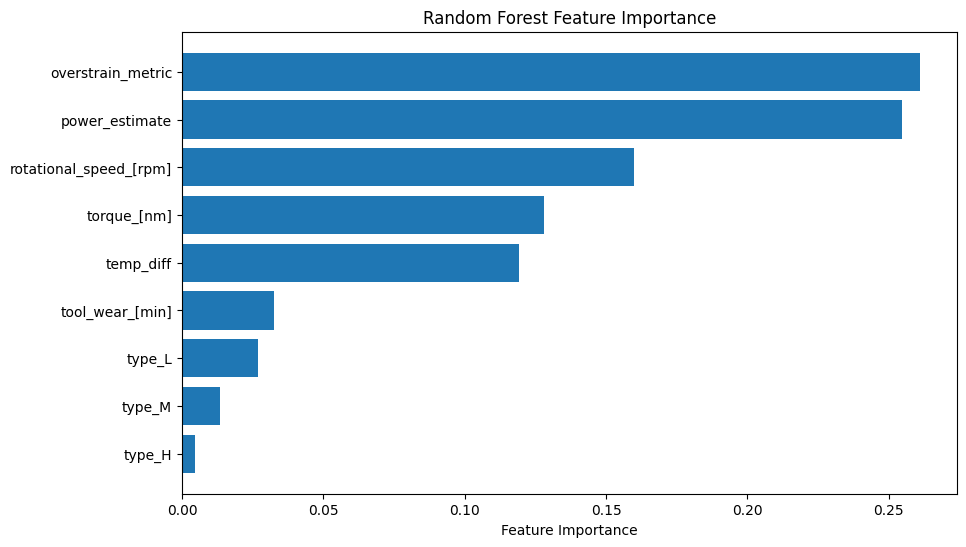

In [ ]:
forest = final_pipeline.named_steps['classifier']
importances = forest.feature_importances_
feature_names = features.columns

feature_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feature_df = feature_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feature_df['feature'], feature_df['importance'])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()


Top features that impact the model's decisions:

1. overstrain_metric: combines torque and tool wear to identify overstrain
2. power_estimate: which captures overall machine load and usage

## Enhancements

- Consider better balancing of the data set as there is a bias towards "No Failure"
- Extend the model to predict multiple simultaneous failures per machine, rather than only the prioritized primary_failure.
- Consider removing RNF and Unknown data points, both which are harder to predict based on the data provided, as they may be causing noise for the model.